# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load Data

**Load dataset**

In [4]:
df = pd.read_csv('data/Weather_Data.csv', index_col='Date/Time', parse_dates=True)

**First look at data**

In [5]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (8784, 7)

First 5 rows:


,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
Date/Time,,,,,,,
2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog


# Data Info

**General info about dataset**

In [6]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe())

=== Dataset Info ===
<class 'pandas.DataFrame'>
DatetimeIndex: 8784 entries, 2012-01-01 00:00:00 to 2012-12-31 23:00:00
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temp_C            8784 non-null   float64
 1   Dew Point Temp_C  8784 non-null   float64
 2   Rel Hum_%         8784 non-null   int64  
 3   Wind Speed_km/h   8784 non-null   int64  
 4   Visibility_km     8784 non-null   float64
 5   Press_kPa         8784 non-null   float64
 6   Weather           8784 non-null   str    
dtypes: float64(4), int64(2), str(1)
memory usage: 549.0 KB
None

=== Missing Values ===
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

=== Basic Statistics ===
            Temp_C  Dew Point Temp_C    Rel Hum_%  Wind Speed_km/h  \
count  8784.000000       8784.000000  8784.000000      8784.000000   
mea

#  Preprocessing

In [12]:
print(df.index)
print(type(df.index))

DatetimeIndex(['2012-01-01 00:00:00', '2012-01-01 01:00:00',
               '2012-01-01 02:00:00', '2012-01-01 03:00:00',
               '2012-01-01 04:00:00', '2012-01-01 05:00:00',
               '2012-01-01 06:00:00', '2012-01-01 07:00:00',
               '2012-01-01 08:00:00', '2012-01-01 09:00:00',
               ...
               '2012-12-31 14:00:00', '2012-12-31 15:00:00',
               '2012-12-31 16:00:00', '2012-12-31 17:00:00',
               '2012-12-31 18:00:00', '2012-12-31 19:00:00',
               '2012-12-31 20:00:00', '2012-12-31 21:00:00',
               '2012-12-31 22:00:00', '2012-12-31 23:00:00'],
              dtype='datetime64[us]', name='Date/Time', length=8784, freq=None)
<class 'pandas.DatetimeIndex'>


**Select important columns**

In [8]:
df = df[['Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Weather']]
df

,Temp_C,Rel Hum_%,Wind Speed_km/h,Weather
Date/Time,,,,
2012-01-01 00:00:00,-1.8,86,4,Fog
2012-01-01 01:00:00,-1.8,87,4,Fog
2012-01-01 02:00:00,-1.8,89,7,"Freezing Drizzle,Fog"
2012-01-01 03:00:00,-1.5,88,6,"Freezing Drizzle,Fog"
2012-01-01 04:00:00,-1.5,88,7,Fog
...,...,...,...,...
2012-12-31 19:00:00,0.1,81,30,Snow
2012-12-31 20:00:00,0.2,83,24,Snow
2012-12-31 21:00:00,-0.5,93,28,Snow


**Rename columns for easier access**

In [10]:
df.columns = ['Temperature', 'Humidity', 'Wind_Speed', 'Weather']
df.columns

Index(['Temperature', 'Humidity', 'Wind_Speed', 'Weather'], dtype='str')

In [18]:
print(df.head())

                     Temperature  Humidity  Wind_Speed               Weather
Date/Time                                                                   
2012-01-01 00:00:00         -1.8        86           4                   Fog
2012-01-01 01:00:00         -1.8        87           4                   Fog
2012-01-01 02:00:00         -1.8        89           7  Freezing Drizzle,Fog
2012-01-01 03:00:00         -1.5        88           6  Freezing Drizzle,Fog
2012-01-01 04:00:00         -1.5        88           7                   Fog


# Statistical Analysis

**Calculate mean temperature and max wind speed**

In [ ]:
mean_temp = df['Temperature'].mean()
max_wind = df['Wind_Speed'].max()

**Find hottest and most humid day**

In [16]:
hottest_day = df['Temperature'].idxmax()
most_humid_day = df['Humidity'].idxmax()

In [17]:
print("=== Statistical Analysis ===")
print(f"Mean Temperature:      {mean_temp:.2f} °C")
print(f"Max Wind Speed:        {max_wind} km/h")
print(f"Hottest Day:           {hottest_day}")
print(f"Most Humid Day:        {most_humid_day}")

=== Statistical Analysis ===
Mean Temperature:      8.80 °C
Max Wind Speed:        83 km/h
Hottest Day:           2012-06-21 15:00:00
Most Humid Day:        2012-03-17 10:00:00


# Create Rainfall Column

In [23]:
df['Rainfall'] = df['Weather'].apply(lambda x: 1 if 'Rain' in x or 'Snow' in x else 0)

print(f"Rainy/Snowy hours: {df['Rainfall'].sum()}")
print(f"Clear hours: {(df['Rainfall'] == 0).sum()}")
df[['Weather', 'Rainfall']].head(10)

Rainy/Snowy hours: 1245
Clear hours: 7539


,Weather,Rainfall
Date/Time,,
2012-01-01 00:00:00,Fog,0
2012-01-01 01:00:00,Fog,0
2012-01-01 02:00:00,"Freezing Drizzle,Fog",0
2012-01-01 03:00:00,"Freezing Drizzle,Fog",0
2012-01-01 04:00:00,Fog,0
2012-01-01 05:00:00,Fog,0
2012-01-01 06:00:00,Fog,0
2012-01-01 07:00:00,Fog,0
2012-01-01 08:00:00,Fog,0


## Filter Data for January 2012

**Filter the dataset for January 2012 using datetime index slicing**

In [25]:
january_data = df.loc['2012-01']
january_data 

,Temperature,Humidity,Wind_Speed,Weather,Rainfall
Date/Time,,,,,
2012-01-01 00:00:00,-1.8,86,4,Fog,0
2012-01-01 01:00:00,-1.8,87,4,Fog,0
2012-01-01 02:00:00,-1.8,89,7,"Freezing Drizzle,Fog",0
2012-01-01 03:00:00,-1.5,88,6,"Freezing Drizzle,Fog",0
2012-01-01 04:00:00,-1.5,88,7,Fog,0
...,...,...,...,...,...
2012-01-31 19:00:00,-7.7,78,19,Snow,1
2012-01-31 20:00:00,-7.4,77,20,Snow,1
2012-01-31 21:00:00,-7.1,77,20,Cloudy,0


**Print the total number of records found for this month**

In [26]:
print(f"Total records found for January 2012: {len(january_data)} rows")

Total records found for January 2012: 744 rows


**Display the first 5 rows of the filtered January data**

In [27]:
january_data.head()

,Temperature,Humidity,Wind_Speed,Weather,Rainfall
Date/Time,,,,,
2012-01-01 00:00:00,-1.8,86,4,Fog,0
2012-01-01 01:00:00,-1.8,87,4,Fog,0
2012-01-01 02:00:00,-1.8,89,7,"Freezing Drizzle,Fog",0
2012-01-01 03:00:00,-1.5,88,6,"Freezing Drizzle,Fog",0
2012-01-01 04:00:00,-1.5,88,7,Fog,0


## 7. Temperature and Rainfall Plot

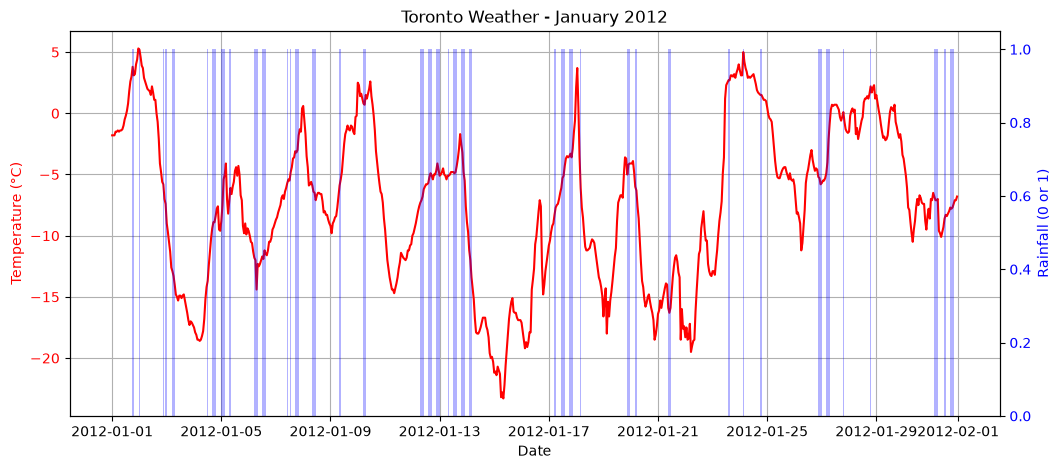

In [33]:
# Setup figure and primary axis for temperature
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature (°C)", color="red")
ax1.plot(january_data.index, january_data["Temperature"], color="red")
ax1.tick_params(axis="y", labelcolor="red")
ax1.grid(True)

# Setup secondary axis for rainfall
ax2 = ax1.twinx()
ax2.set_ylabel("Rainfall (0 or 1)", color="blue")
ax2.bar(
    january_data.index,
    january_data["Rainfall"],
    color="blue",
    alpha=0.3,
    width=0.02,
)
ax2.tick_params(axis="y", labelcolor="blue")

plt.title("Toronto Weather - January 2012")
plt.show()